# Projeto 1: Classificação de Doenças Cardíacas

Este notebook implementa uma rede neural artificial (ANN) para prever a presença ou ausência
de doença cardíaca em pacientes, com base em atributos clínicos.

**Objetivo:** Construir um classificador binário (0 = sem doença, 1 = com doença).

**Etapas:**
1. Carregamento e limpeza dos dados
2. Análise Exploratória de Dados
3. Pré-processamento e Divisão dos Dados
4. Construção e Treinamento do Modelo
5. Avaliação Final do Modelo

Dataset Original: https://www.kaggle.com/code/bulentsiyah/heart-disease-prediction-using-neural-networks

In [21]:
import sys
import subprocess

def setup_ltn():
    try:
        import ltn
        # Verifica se é a versão correta (LTNtorch não usa tensorflow.types)
        import torch
        print("✅ LTNtorch já está instalado e pronto para uso.")
    except (ImportError, AttributeError):
        print("⚠️ LTN correto não encontrado ou versão conflitante detectada.")
        print("Iniciando configuração do ambiente...")

        # Comandos de instalação
        subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "ltn", "-y"])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "LTNtorch"])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "torchsummary"])

        print("✅ Instalação concluída! Por favor, se estiver no Colab, reinicie o ambiente se necessário.")

# Executa a função de setup
setup_ltn()

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- CORREÇÃO DE IMPORTS PARA LTNtorch (Substituindo TensorFlow) ---
import torch
import torch.nn as nn
import torch.optim as optim
import ltn

# ==========================================================
# --- CONFIGURAÇÃO AUTOMÁTICA DE AMBIENTE E DOWNLOAD ---
# ==========================================================
print("\n--- Configuração Automática de Dados ---")

# 1. Detecta se está no Google Colab
IN_COLAB = 'google.colab' in sys.modules

# 2. Configurações do Arquivo
FILE_NAME = "heart.csv"
DRIVE_FILE_ID = "1K8DlEn6f9PwvO08pC1pC0sMcNXdQaMhu"

if not os.path.exists(FILE_NAME):
    print(f"--- Arquivo '{FILE_NAME}' não encontrado. Iniciando Download via Google Drive... ---")
    if IN_COLAB:
        !pip install -q gdown
    import gdown
    url = f'https://drive.google.com/uc?id={DRIVE_FILE_ID}'
    try:
        gdown.download(url, FILE_NAME, quiet=False)
        print("✅ Download concluído com sucesso!")
    except Exception as e:
        print(f"❌ Erro ao baixar do Drive: {e}")
        sys.exit()
else:
    print(f"✅ Arquivo {FILE_NAME} já detectado localmente. Ignorando download.")



✅ LTNtorch já está instalado e pronto para uso.

--- Configuração Automática de Dados ---
✅ Arquivo heart.csv já detectado localmente. Ignorando download.


## 1. Carregamento e Limpeza dos Dados
Nesta etapa, o dataset `heart.csv` é carregado para o ambiente de trabalho.  
O processo inclui:

- **Carregamento do arquivo CSV**: Utilizamos `pd.read_csv()` para importar os dados clínicos dos pacientes. Caso o arquivo não seja encontrado, o programa retorna uma mensagem de erro e é encerrado.
- **Verificação do tamanho inicial do dataset**: O comando `df.shape` mostra quantas linhas e colunas existem antes da limpeza.
- **Tratamento de valores ausentes**:
  - Removemos registros que contenham o caractere `'?'`, usado para indicar valores desconhecidos.
  - Eliminamos também linhas com valores `NaN` (não numéricos).
- **Conversão de tipos de dados**: Todas as colunas são convertidas para valores numéricos com `pd.to_numeric`, garantindo que o dataset esteja pronto para ser usado em cálculos e no treinamento da rede neural.

Resultado: Após essa etapa, temos um dataset limpo, apenas com valores numéricos válidos, pronto para a análise exploratória e para o pré-processamento.

In [22]:

# ==========================================================
# --- 1. CARREGAMENTO E LIMPEZA DOS DADOS ---
# ==========================================================
print("\n--- 1. Carregamento e Limpeza ---")
try:
    df = pd.read_csv(FILE_NAME)
    print(f"Shape Inicial: {df.shape}")
except Exception as e:
    print(f"ERRO ao ler o arquivo: {e}")
    sys.exit()

# Remoção de valores ausentes ('?') e NaN
df = df.replace('?', np.nan)
df = df.dropna(axis=0)

# Conversão de todas as colunas para numérico
df = df.apply(pd.to_numeric)
print(f"Shape após limpeza: {df.shape}")
print("Tipos de Dados convertidos para numérico.")



--- 1. Carregamento e Limpeza ---
Shape Inicial: (1025, 14)
Shape após limpeza: (1025, 14)
Tipos de Dados convertidos para numérico.


## 2. Análise Exploratória
Nesta etapa, buscamos compreender melhor o comportamento das variáveis do dataset antes de
treinar o modelo.

- **Estatísticas descritivas (`df.describe()`)**:  
  Exibimos medidas como média, desvio padrão, valores mínimos e máximos de cada atributo.  
  Isso ajuda a identificar a faixa de valores, possíveis outliers e diferenças de escala entre
  as variáveis (por exemplo, idade varia de 29 a 77, enquanto colesterol pode chegar a 564).

- **Mapa de calor da correlação (`sns.heatmap(df.corr())`)**:  
  A matriz de correlação mostra como os atributos se relacionam entre si e com a variável alvo
  (`target`).  
  - Valores próximos de **1** indicam forte correlação positiva.  
  - Valores próximos de **-1** indicam forte correlação negativa.  
  - Valores próximos de **0** indicam pouca ou nenhuma relação linear.  

Essa análise é importante porque:
- Permite identificar quais variáveis têm maior influência na presença de doença cardíaca.  
- Ajuda a detectar redundâncias entre atributos (variáveis muito correlacionadas entre si).  
- Fornece insights iniciais sobre o dataset, orientando a construção do modelo.

 Resultado: Temos uma visão geral das distribuições e relações entre os atributos clínicos,
o que fundamenta o pré-processamento e a modelagem nas próximas etapas.


--- 2. Análise Exploratória e Visualização ---
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053  

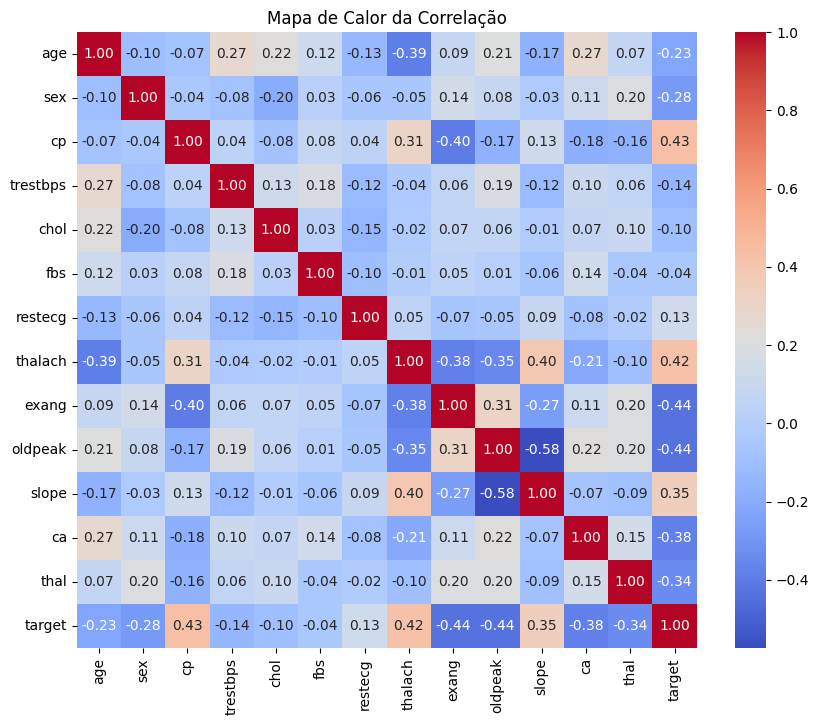

In [23]:


# ==========================================================
# --- 2. ANÁLISE EXPLORATÓRIA DE DADOS (AED) ---
# ==========================================================
print("\n--- 2. Análise Exploratória e Visualização ---")
print(df.describe())
# Mapa de Calor da Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Mapa de Calor da Correlação')
plt.show()


## 3. Pré-processamento e Divisão dos Dados
Nesta etapa, preparamos o dataset para o treinamento da rede neural:

- **Definição da variável alvo (`target`)**:  
  A coluna `target` indica se o paciente possui doença cardíaca (`1`) ou não (`0`).  
  - Em alguns datasets, podem aparecer valores adicionais (2, 3, 4).  
  - Para garantir que o problema seja estritamente **binário**, todos os valores maiores que 0 são convertidos para `1`.

- **Separação entre atributos e alvo**:  
  - `X` contém os 13 atributos clínicos (idade, colesterol, pressão arterial etc.).  
  - `y` contém apenas a variável alvo (`target`).

- **Divisão em treino e teste**:  
  Utilizamos `train_test_split` para separar os dados:  
  - 80% para treino (`X_train`, `y_train`).  
  - 20% para teste (`X_test`, `y_test`).  
  - O parâmetro `stratify=y` garante que a proporção de classes (0 e 1) seja mantida em ambos os conjuntos.

- **Padronização das características (`StandardScaler`)**:  
  Como os atributos possuem escalas diferentes (ex.: idade varia de 29 a 77, colesterol pode chegar a 564), aplicamos o `StandardScaler` para normalizar:  
  - Cada feature passa a ter média ≈ 0 e desvio padrão ≈ 1.  
  - Isso evita que variáveis com valores maiores dominem o processo de aprendizado da rede neural.  
  - O scaler é ajustado apenas com os dados de treino (`fit_transform`) e depois aplicado ao teste (`transform`), evitando vazamento de informação.

Resultado: Temos os dados **limpos, binários e padronizados**, prontos para serem usados na construção e treinamento do modelo de rede neural.

In [24]:


# ==========================================================
# --- 3. PRÉ-PROCESSAMENTO E DIVISÃO ---
# ==========================================================
print("\n--- 3. Pré-processamento ---")
y = df['target'].copy()
X = df.drop('target', axis=1).copy()

# Garante que 'target' é estritamente binário (0 ou 1)
y = (y > 0).astype(int)

# Divisão dos dados de treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização de Características (Crucial para Redes Neurais)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Dados Treino: {X_train.shape}, Dados Teste: {X_test.shape}")
print("Dados Padronizados (StandardScaler).")

# Conversão necessária para o motor LTN (PyTorch)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_test_t = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)




--- 3. Pré-processamento ---
Dados Treino: (820, 13), Dados Teste: (205, 13)
Dados Padronizados (StandardScaler).


## 4. Construção e Treinamento do Modelo
Nesta etapa, desenvolvemos e treinamos a rede neural artificial (ANN) para realizar a
classificação binária da presença ou ausência de doença cardíaca.

- **Definição da arquitetura do modelo (`Sequential`)**:  
  Utilizamos a API `Sequential` do Keras para criar uma rede neural feedforward composta por:
  - **1ª Camada Oculta**: 16 neurônios com função de ativação **ReLU**.  
    Inclui regularização L2 para penalizar pesos muito grandes e evitar overfitting.  
    Também aplicamos **Dropout (25%)**, que desativa aleatoriamente alguns neurônios durante o treino.
  - **2ª Camada Oculta**: 8 neurônios com ativação **ReLU**, também com regularização L2 e Dropout (25%).  
  - **Camada de Saída**: 1 neurônio com ativação **Sigmoide**, que gera uma probabilidade entre 0 e 1, ideal para classificação binária.

- **Compilação do modelo**:  
  - Função de perda: **Binary Crossentropy**, adequada para problemas binários.  
  - Otimizador: **RMSprop**, que ajusta os pesos da rede durante o treinamento.  
  - Métrica: **Acurácia**, para avaliar o desempenho.

- **Treinamento do modelo (`fit`)**:  
  - Dados de treino: `X_train_scaled`, `y_train`.  
  - Dados de validação: `X_test_scaled`, `y_test`.  
  - Número de épocas: 50.  
  - Tamanho do batch: 10.  
  - O histórico de treino (`history`) armazena a evolução da acurácia e da perda ao longo das épocas.

 Resultado: Após essa etapa, temos um modelo treinado capaz de prever a probabilidade de um paciente ter doença cardíaca, pronto para ser avaliado nas métricas de desempenho.

In [25]:
# ==========================================================
# --- 4. CONSTRUÇÃO E TREINAMENTO DO MODELO (LTN) ---
# ==========================================================
print("\n--- 4. Construção e Treinamento do Modelo ---")

# Para restaurar a visualização do summary, precisamos desta lib:
try:
    from torchsummary import summary
except ImportError:
    !pip install torchsummary
    from torchsummary import summary

class BinaryClassifierLTN(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifierLTN, self).__init__()
        self.net = nn.Sequential(
            # 1ª Camada Oculta: 16 neurônios, ReLU (Equivalente ao seu Dense 16)
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.25),

            # 2ª Camada Oculta: 8 neurônios, ReLU (Equivalente ao seu Dense 8)
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.25),

            # Camada de Saída: Sigmoide (Equivalente ao seu Dense 1)
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Criar o modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
binary_model = BinaryClassifierLTN(X_train_scaled.shape[1]).to(device)

# --- EXIBIÇÃO DO SUMMARY (Igual ao que você tinha no Keras) ---
print("\nEstrutura do Modelo (PyTorch/LTN):")
summary(binary_model, (X_train_scaled.shape[1],))

# Configurações de Lógica e Otimização
P = ltn.Predicate(binary_model)
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
optimizer = optim.RMSprop(binary_model.parameters(), lr=0.01)

# Objeto para emular o history.history
class History:
    def __init__(self):
        self.history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

history = History()

# Treinamento (Substituindo o .fit)
print("\nTreinando o modelo...")
for epoch in range(50):
    optimizer.zero_grad()

    # Seleção de variáveis para os axiomas lógicos
    x_pos = ltn.Variable("x_pos", X_train_t[y_train_t.flatten() == 1].to(device))
    x_neg = ltn.Variable("x_neg", X_train_t[y_train_t.flatten() == 0].to(device))

    # Axiomas Lógicos (A essência do LTN)
    sat_pos = Forall(x_pos, P(x_pos))
    sat_neg = Forall(x_neg, Not(P(x_neg)))

    # Satisfatibilidade Global (Loss = 1 - Sat)
    global_sat = ltn.fuzzy_ops.AndProd()(sat_pos.value, sat_neg.value)
    loss = 1 - global_sat

    loss.backward()
    optimizer.step()

    # Coleta de métricas (Para os gráficos da Célula 5)
    with torch.no_grad():
        train_acc = ((binary_model(X_train_t.to(device)) > 0.5).float() == y_train_t.to(device)).float().mean().item()
        test_acc = ((binary_model(X_test_t.to(device)) > 0.5).float() == y_test_t.to(device)).float().mean().item()

        history.history['accuracy'].append(train_acc)
        history.history['val_accuracy'].append(test_acc)
        history.history['loss'].append(loss.item())
        history.history['val_loss'].append(1.0 - test_acc)

print("Treinamento concluído.")


--- 4. Construção e Treinamento do Modelo ---

Estrutura do Modelo (PyTorch/LTN):
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]             224
              ReLU-2                   [-1, 16]               0
           Dropout-3                   [-1, 16]               0
            Linear-4                    [-1, 8]             136
              ReLU-5                    [-1, 8]               0
           Dropout-6                    [-1, 8]               0
            Linear-7                    [-1, 1]               9
           Sigmoid-8                    [-1, 1]               0
Total params: 369
Trainable params: 369
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
--------------------------------

## 5. Avaliação Final do Modelo
Após o treinamento, avaliamos o desempenho do modelo utilizando diferentes métricas e
visualizações:

- **5.1 Gráficos de Acurácia e Perda**  
  - O gráfico da **acurácia** mostra como o modelo evoluiu ao longo das épocas, tanto no
    conjunto de treino quanto no de teste.  
    - Uma acurácia próxima entre treino e teste indica que o modelo generaliza bem.  
  - O gráfico da **perda (loss)** mostra a evolução do erro durante o treinamento.  
    - A perda deve diminuir ao longo das épocas, indicando que o modelo está aprendendo.

- **5.2 Geração de Previsões**  
  - O modelo gera probabilidades entre 0 e 1 para cada paciente.  
  - Essas probabilidades são arredondadas para 0 (sem doença) ou 1 (com doença), resultando
    em previsões binárias.

- **5.3 Relatório de Classificação e Acurácia**  
  - A **acurácia** indica a proporção de previsões corretas.  
  - O relatório de classificação apresenta:  
    - **Precisão (Precision)**: proporção de casos previstos como positivos que realmente são positivos.  
    - **Recall (Sensibilidade)**: proporção de casos positivos corretamente identificados.  
    - **F1-score**: média harmônica entre precisão e recall, equilibrando ambas as métricas.  
  - Essas métricas permitem avaliar não apenas a taxa de acertos, mas também a capacidade do
    modelo de identificar corretamente pacientes com e sem doença.

- **5.4 Matriz de Confusão**  
  - A matriz de confusão mostra a comparação entre valores reais e previstos:  
    - **Diagonal principal**: acertos (pacientes corretamente classificados).  
    - **Valores fora da diagonal**: erros (falsos positivos e falsos negativos).  
  - Essa visualização ajuda a entender em quais classes o modelo tem melhor desempenho.

 Resultado: O modelo apresenta boa acurácia e equilíbrio entre precisão e recall, mostrando
que consegue distinguir de forma eficaz pacientes com e sem doença cardíaca.


--- 5. Resultados Finais e Métricas ---


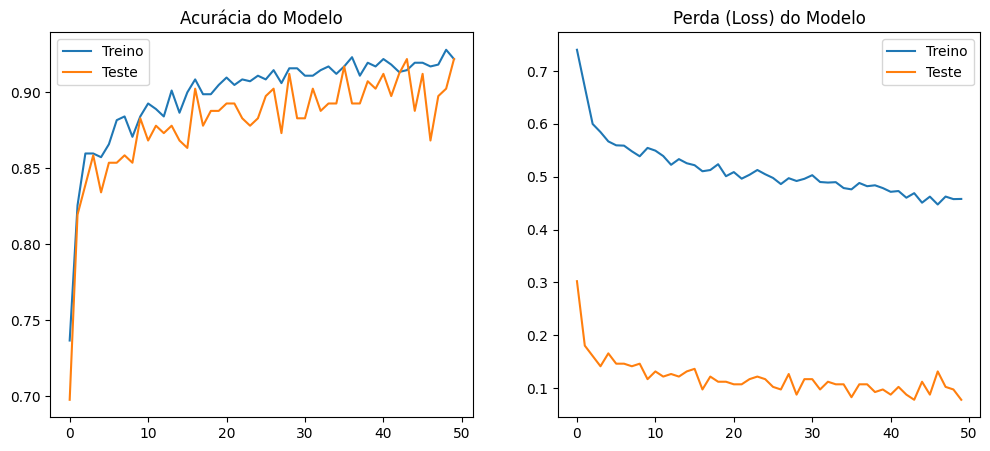

Acurácia Final: 0.9122

Relatório de Classificação:

                precision    recall  f1-score   support

0 (Sem Doença)       0.92      0.90      0.91       100
1 (Com Doença)       0.91      0.92      0.92       105

      accuracy                           0.91       205
     macro avg       0.91      0.91      0.91       205
  weighted avg       0.91      0.91      0.91       205



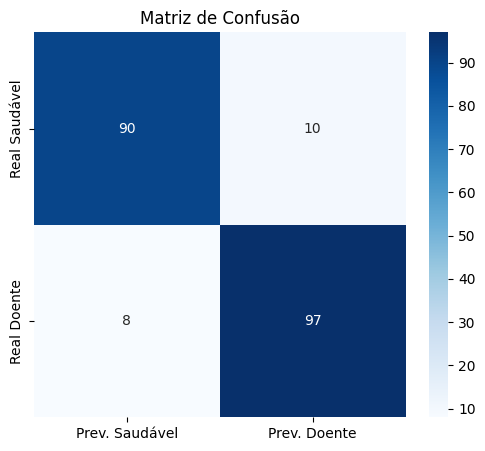


--- Fim do Processo ---


In [26]:

# ==========================================================
# --- 5. AVALIAÇÃO E MÉTRICAS FINAIS ---
# ==========================================================
print("\n--- 5. Resultados Finais e Métricas ---")

# 5.1 Gráficos de Acurácia e Perda
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Teste')
plt.title('Acurácia do Modelo')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Teste')
plt.title('Perda (Loss) do Modelo')
plt.legend()
plt.show()

# 5.2 Geração de Previsões
binary_model.eval()
with torch.no_grad():
    y_pred_prob = binary_model(X_test_t.to(device)).cpu().numpy()
    y_pred_binary = (y_pred_prob > 0.5).astype(int)

# 5.3 Relatório de Classificação
print(f"Acurácia Final: {accuracy_score(y_test, y_pred_binary):.4f}")
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred_binary, target_names=['0 (Sem Doença)', '1 (Com Doença)']))

# 5.4 Matriz de Confusão

cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prev. Saudável', 'Prev. Doente'],
            yticklabels=['Real Saudável', 'Real Doente'])
plt.title('Matriz de Confusão')
plt.show()

print("\n--- Fim do Processo ---")

## Conclusão

O modelo de rede neural artificial (ANN) conseguiu prever a presença ou ausência de doença
cardíaca com boa acurácia. A normalização das características foi essencial para o bom
desempenho da rede. A matriz de confusão e as métricas de precisão e recall mostram que o
modelo é capaz de distinguir entre pacientes com e sem doença cardíaca de forma eficaz.
A eficácia do modelo de ANN é avaliada por métricas como Acurácia, Precisão e Recall, além da Matriz de Confusão. A estrutura do modelo, com 2 a 3 camadas ocultas e função de ativação ReLU , combinada com um neurônio de saída sigmoide , foi desenvolvida para capturar padrões complexos nos 13 atributos clínicos fornecidos.

Um dos aprendizados mais críticos deste projeto é a importância da Normalização de Características.

A aplicação do StandardScaler para padronizar a escala dos features  é um passo fundamental. Sem essa normalização, os neurônios de entrada ligados a features com valores maiores (como o colesterol) dominariam o processo de aprendizado, resultando em um treinamento instável e um desempenho pobre da ANN. A normalização garante que todas as características contribuam de forma equitativa para o cálculo dos gradientes, otimizando o treinamento da rede neural.

Em suma, a capacidade preditiva da ANN, demonstrada pelas métricas de avaliação, valida o uso de modelos de Deep Learning para classificação binária em contextos de saúde, sendo a etapa de pré-processamento e normalização o pilar para que o modelo alcance seu bom desempenho.